In [1]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
import re

In [2]:
whole = pd.ExcelFile('Data_Coded.xlsx')
whole

In [3]:
thread = pd.read_excel(whole, 'Thread').fillna('')
thread

,id,user_id,commentable_id,course_id,closed,thread_type,title,body,CP Code,anonymous,anonymous_to_peers,comment_count,upvotes,downvotes,last_activity_at,updated_at,created_at,random number,coding researcher
0,\x35386137323138386461643636633038323330303039...,13712938,gt-cs1301x-General-Discussion,course-v1:GTx+CS1301x+1T2017,False,discussion,Blanks in your code,I noticed that in 2.3.5 BOOLEAN OPERATORS IN P...,1,False,False,2,0,0,2017-03-07 22:48:00,2017-03-07 22:48:00,2017-02-17 16:15:00,5.65141e-05,jonna
1,\x35633333633366663365623965363039643630303037...,17666899,a154b4631cf5d5e5f067fd4ef4cbb30844ba08eb,course-v1:GTx+CS1301xI+1T2019,False,discussion,Interesting!,Let's go further for getting more boost,0,False,False,5,0,0,2019-10-01 17:04:00,2019-10-01 17:04:00,2019-01-07 21:26:00,0.000494318,jonna
2,\x35636533373839366438656162313039363630303138...,23228646,d75bc9f21aa953b6a0d3ad841a56bd4735fccb36,course-v1:GTx+CS1301xIV+1T2019,False,discussion,yey,yey,0,False,False,4,0,0,2019-09-09 19:24:00,2019-09-09 19:24:00,2019-05-21 04:03:00,0.00133903,jonna
3,\x35623463353638366335323634383039613230303137...,19945474,gt-cs1301x-General-Discussion,course-v1:GTx+CS1301x+1T2017,False,question,certificate,Am I getting certificate after completing this...,0,False,False,0,0,0,2018-07-16 08:25:00,2018-07-16 08:25:00,2018-07-16 08:25:00,0.00134963,jonna
4,\x35386337333566303962653431643039323830303161...,8558517,gt-cs1301x-General-Discussion,course-v1:GTx+CS1301x+1T2017,False,discussion,need help on 3.2.2,would some body please check my code out of 10...,1,False,False,5,0,0,2017-03-14 16:36:00,2017-03-14 16:36:00,2017-03-14 00:14:00,0.00217223,jonna
5,\x35623438666565393763366531643039636330303135...,18718334,gt-cs1301x-General-Discussion,course-v1:GTx+CS1301xI+1T2018,False,discussion,Anybody can PERSON to Code: Link broken,Anybody can PERSON to Code: Inspirational intr...,1,False,False,3,0,0,2018-10-05 15:11:00,2018-10-05 15:11:00,2018-07-13 19:35:00,0.00313858,jonna
6,\x35636535643135303530376137613039623730303161...,22081517,gt-cs1301x-General-Discussion,course-v1:GTx+CS1301xI+1T2019,False,discussion,Error message,When doing the practice exam or any questions ...,1,False,False,1,0,0,2019-06-11 12:44:00,2019-06-11 12:44:00,2019-05-22 22:46:00,0.00324542,jonna
7,\x35626464633531623336313031333039383930303134...,212143,gt-cs1301x-General-Discussion,course-v1:GTx+CS1301xI+3T2018,False,question,Wrong answer in Smartbook Exercise,In the smartbook one of the questions asks >...,1,False,True,0,0,0,2018-11-03 15:56:00,2018-11-03 15:58:00,2018-11-03 15:56:00,0.00352175,jonna
8,\x35613439323061386435636237373061386130303039...,16843627,gt-cs1301x-5-1,course-v1:GTx+CS1301x+1T2017,False,discussion,5.1.4 Coding Exercise 2,"Anyone around, Please, what could be the probl...",1,False,False,7,0,0,2017-12-31 22:17:00,2017-12-31 22:17:00,2017-12-31 17:38:00,0.0036465,jonna
9,\x35636535633830386438656162313039353830303161...,21116796,gt-cs1301x-4-4,course-v1:GTx+CS1301xIII+1T2019,False,question,Vocareum message ../resource/scripts/submit.sh...,I've found the solution of Coding Problem 4.4....,1,False,False,3,1,0,2019-05-23 21:26:00,2019-05-23 21:26:00,2019-05-22 22:07:00,0.00373672,jonna


In [4]:
thread_extract = thread[['body','CP Code']]
thread_list = thread_extract.values.tolist()
thread_list

[['I noticed that in 2.3.5 BOOLEAN OPERATORS IN PYTHON SANDBOX (EXTERNAL RESOURCE) you had a blank in line 5 so the code would not run until this was removed. It happened in some other instances as well but I did not write them down. Is that intented? ',
  1],
 ["Let's go further for getting more boost", 0],
 ['yey', 0],
 ['Am I getting certificate after completing this python course....?', 0],
 ['would some body please check my code out of 10, i got 6 correct:   restaurant = \'\'          if (hour >= 12) and (hour >= 1) and (minute <= 33):            restaurant = \'Taco Bell\'              elif (hour >= 12) and (hour >= 2) and (minute <= 47):            restaurant = \'Cookout\'              else:         restaurant = \'PERSON PERSON\'          return restaurant   #You may modify the following code to check your work hour = 1 minute = 33 print("Restaurant:", lateNightNoms(hour, minute))  thanks',
  1],
 ["Anybody can PERSON to Code: Inspirational introduction to Hour of Code. the page 

In [5]:
comment = pd.read_excel(whole, 'Comments').fillna('')
comment

,id,thread_id,parent_id,user_id,course_id,body,CP Code,anonymous,anonymous_to_peers,upvotes,downvotes,abuse_flagger_count,historical_abuse_flagger_count,endorsed,endorser_id,endorsement_time,updated_at,created_at,random number,coding researcher
0,\x35383966363961313962653431643038666530303036...,\x35383937663961346461643636633038306530303032...,,10779186,course-v1:GTx+CS1301x+1T2017,[deleted],0,False,False,0,0,0,0,False,,,2019-04-17 19:17:00,2017-02-11 19:44:00,0.000382695,jonna
1,\x35396231393534396263303461363061313330303035...,\x35396231383537643465643734393039643630303034...,,14429895,course-v1:GTx+CS1301x+1T2017,"It would help to see the indentation, by eithe...",2,False,False,0,0,0,0,False,,,2017-09-08 01:59:00,2017-09-07 18:51:00,0.000383145,jonna
2,\x35613639666635363933373934303061303630303030...,\x35613638643465326231343137313039336330303033...,\x35613638666364323234343531613039613930303030...,16308333,course-v1:GTx+CS1301x+1T2017,Please check my other post on this subject.,3,False,False,0,0,0,0,False,,,2018-01-25 16:01:00,2018-01-25 16:01:00,0.000586266,jonna
3,\x35653063353733323935623036323039353930303262...,\x35653062326166333935623036323039353930303261...,,6146518,course-v1:GTx+CS1301xIII+1T2019,it has been fixed,0,False,False,1,0,0,0,False,,,2020-01-01 08:24:00,2020-01-01 08:24:00,0.00064325,jonna
4,\x35636536303330306438656162313039373630303161...,\x35636535626565333064616663363039633330303162...,\x35636535663632343530376137613039663030303162...,23563718,course-v1:GTx+CS1301xIII+1T2019,I'm having the same problem. Ugh!!! I was in...,1,False,False,0,0,0,0,False,,,2019-05-23 02:18:00,2019-05-23 02:18:00,0.000889033,jonna
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,\x35386463646139613962653431643039323530303235...,\x35386430326135616631373035363037633230303166...,\x35386462653236363962653431643038663230303235...,14046218,course-v1:GTx+CS1301x+1T2017,"Test 4: When num2=17, num1=2, your code incorr...",4,False,False,0,0,0,0,False,,,2017-03-30 10:14:00,2017-03-30 10:14:00,,
537,\x35386463646138316461643636633038336530303239...,\x35386430326135616631373035363037633230303166...,\x35386462653236363962653431643038663230303235...,14046218,course-v1:GTx+CS1301x+1T2017,i ran into another issue here i did all the st...,1,False,False,0,0,0,0,False,,,2017-03-30 10:14:00,2017-03-30 10:14:00,,
538,\x35386462656165346461643636633038306530303262...,\x35386430326135616631373035363037633230303166...,\x35386462653236363962653431643038663230303235...,14046218,course-v1:GTx+CS1301x+1T2017,ooooooohhh okok thnx again m8,0,False,False,0,0,0,0,False,,,2017-03-29 17:12:00,2017-03-29 17:12:00,,
539,\x35386462653236363962653431643038663230303235...,\x35386430326135616631373035363037633230303166...,,14046218,course-v1:GTx+CS1301x+1T2017,Im so confused by this problem,1,False,False,0,0,0,0,False,,,2017-03-29 16:35:00,2017-03-29 16:35:00,,


In [6]:
comment_extract = comment[['body','CP Code']]
comment_list = comment_extract.values.tolist()
comment_list

[['[deleted]', 0],
 ["It would help to see the indentation, by either including a screenshot, or pasting using the code button (1s and 0's) above the text entry area, then checking that the preview matches your code.",
  2],
 ['Please check my other post on this subject. ', 3],
 ['it has been fixed', 0],
 ["I'm having the same problem.  Ugh!!!  I was in the zone and making great progress :-(  Hopefully it will be resolved soon.  I'm glad It's not just me having the issue.  [Executed at: Wed May 22 19:09:49 PDT 2019]  ./.vocSubmissionShellScriptInternal_316113.sh: line 5: ../resource/scripts/submit.sh: No such file or directory Command exited with non-zero status 1",
  1],
 ["You're perhaps concentrating on fixed values, that may only apply when `amount`is 67.  If say, `quarters = amount // 25`  you might then subtract the value of `quarters * 25` from amount, to get the next number.  ",
  2],
 ["try this:  if text[i] == ' ':          if text[i+1] != ' ':               word_count += 1 G

In [7]:
code0_list = [i for i in thread_list if i[1] == 0] + [i for i in comment_list if i[1] == 0] 
code1_list = [i for i in thread_list if i[1] == 1] + [i for i in comment_list if i[1] == 1]
code2_list = [i for i in thread_list if i[1] == 2] + [i for i in comment_list if i[1] == 2] 
code3_list = [i for i in thread_list if i[1] == 3] + [i for i in comment_list if i[1] == 3] 
code4_list = [i for i in thread_list if i[1] == 4] + [i for i in comment_list if i[1] == 4] 

In [8]:
amount_dict = {'code0':len(code0_list), 'code1':len(code1_list),'code2':len(code2_list), 'code3':len(code3_list), 'code4':len(code4_list)}
amount_dict

{'code0': 196, 'code1': 89, 'code2': 107, 'code3': 106, 'code4': 85}

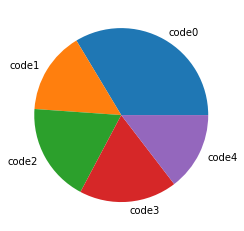

In [9]:
plt.pie(amount_dict.values(), labels = amount_dict.keys())
plt.show()

In [10]:
import nltk
stopwords = nltk.corpus.stopwords.words('english')
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer("english")


In [11]:
# tokenization and stemming
def tokenization_and_stemming(text):
    # exclude stop words and tokenize the post, generate a list of string 
    tokens = [word.lower() for sent in nltk.sent_tokenize(text) for word in nltk.word_tokenize(sent) if word not in stopwords]
    filtered_tokens = []
    # filter out any tokens not containing letters (e.g., numeric tokens, raw punctuation)
    for token in tokens:
        if re.search('[a-zA-Z]', token):
            filtered_tokens.append(token)       
    # stemming
    stems = [stemmer.stem(t) for t in filtered_tokens]
    return stems

# tokenization without stemming
def tokenization(text):
    tokens = [word.lower() for sent in nltk.sent_tokenize(text) for word in nltk.word_tokenize(sent) if word not in stopwords]
    filtered_tokens = []
    for token in tokens:
        if re.search('[a-zA-Z]', token):
            filtered_tokens.append(token)
    return filtered_tokens

In [12]:
combined_list = [code0_list, code1_list, code2_list, code3_list, code4_list]

In [13]:
#code 0
tok_and_stem0 = []
tok0 = []
for i in code0_list:
    tok_and_stem0.extend(tokenization_and_stemming(str(i[0])))
    tok0.extend(tokenization(str(i[0])))
fdist0 = FreqDist(tok_and_stem0)
fdist0.most_common(20)


[('i', 215),
 ('person', 90),
 ('cours', 55),
 ('thank', 54),
 ('def', 30),
 ("n't", 27),
 ('self', 27),
 ('work', 26),
 ('code', 24),
 ("'s", 23),
 ('learn', 22),
 ('see', 22),
 ("'m", 22),
 ('https', 21),
 ('print', 21),
 ('problem', 18),
 ('program', 18),
 ('x', 18),
 ('return', 18),
 ('python', 17)]

In [14]:
#code 1
tok_and_stem1 = []
tok1 = []
for i in code1_list:
    tok_and_stem1.extend(tokenization_and_stemming(str(i[0])))
    tok1.extend(tokenization(str(i[0])))
fdist1 = FreqDist(tok_and_stem1)
fdist1.most_common(20)

[('i', 153),
 ('code', 84),
 ('print', 75),
 ('return', 45),
 ("n't", 30),
 ('person', 29),
 ('problem', 26),
 ('hour', 25),
 ('answer', 25),
 ('line', 23),
 ('get', 23),
 ('def', 21),
 ('valu', 21),
 ('run', 20),
 ('els', 20),
 ('result', 20),
 ('error', 20),
 ('correct', 19),
 ('chang', 19),
 ('type', 18)]

In [15]:
#code 2
tok_and_stem2 = []
tok2 = []
for i in code2_list:
    tok_and_stem2.extend(tokenization_and_stemming(str(i[0])))
    tok2.extend(tokenization(str(i[0])))
fdist2 = FreqDist(tok_and_stem2)
fdist2.most_common(20)

[('i', 138),
 ('code', 66),
 ("n't", 42),
 ('print', 34),
 ('error', 30),
 ('tri', 29),
 ('result', 28),
 ("'s", 26),
 ('use', 25),
 ('get', 23),
 ('problem', 22),
 ('answer', 21),
 ('hour', 21),
 ('true', 20),
 ('valu', 20),
 ('would', 19),
 ('run', 19),
 ('line', 17),
 ('test', 17),
 ('person', 16)]

In [16]:
#code 3
tok_and_stem3 = []
tok3 = []
for i in code3_list:
    tok_and_stem3.extend(tokenization_and_stemming(str(i[0])))
    tok3.extend(tokenization(str(i[0])))
fdist3 = FreqDist(tok_and_stem3)
fdist3.most_common(20)

[('i', 79),
 ('code', 47),
 ("'s", 32),
 ("n't", 28),
 ('person', 26),
 ('use', 26),
 ('line', 25),
 ('print', 24),
 ('tri', 21),
 ('assign', 21),
 ('problem', 21),
 ('the', 20),
 ('work', 20),
 ('variabl', 20),
 ('get', 19),
 ('thank', 17),
 ('valu', 17),
 ('one', 17),
 ('if', 17),
 ('error', 16)]

In [17]:
#code 4
tok_and_stem4 = []
tok4 = []
for i in code4_list:
    tok_and_stem4.extend(tokenization_and_stemming(str(i[0])))
    tok4.extend(tokenization(str(i[0])))
fdist4 = FreqDist(tok_and_stem4)
fdist4.most_common(20)

[('person', 84),
 ('print', 66),
 ('i', 58),
 ('code', 49),
 ('return', 39),
 ('result', 35),
 ('you', 34),
 ('valu', 34),
 ("n't", 31),
 ('true', 31),
 ('use', 30),
 ('the', 28),
 ('need', 28),
 ('line', 26),
 ('function', 25),
 ('test', 25),
 ('b', 21),
 ('one', 20),
 ('problem', 20),
 ('tri', 20)]

We can't really see any words that are particular to each phase. The words with high frequencies appear in all phases. 

In [18]:
#write combined_list to a csv file
import csv
with open('combined_list.csv','w') as fout:
    writer = csv.writer(fout)
    for i in combined_list:
        writer.writerows(i)

In [19]:
import json
sentiment_dict = json.load(open('sentiment_output.json'))
sentiment_dict

{'0': [0.25,
  0.0,
  0.0,
  0.603125,
  0.0510204081632653,
  0.0,
  0.0,
  -0.08249999999999999,
  0.0,
  0.1,
  0.0,
  -0.125,
  0.35,
  0.0,
  0.8125,
  0.16666666666666666,
  0.2,
  0.0,
  0.28409090909090906,
  0.0,
  0.5625,
  0.1852272727272727,
  0.0,
  0.0,
  0.3666666666666667,
  0.16666666666666666,
  0.0,
  0.23666666666666666,
  0.0,
  -0.75,
  0.0,
  0.12291666666666666,
  -0.05,
  0.09821428571428571,
  0.0,
  -0.3500000000000001,
  0.033333333333333326,
  0.0,
  0.2857142857142857,
  0.0,
  0.0,
  0.0,
  0.2,
  0.13636363636363635,
  0.0,
  0.0,
  0.0,
  0.2875,
  0.0,
  0.0,
  1.0,
  1.0,
  0.2673376623376623,
  0.8,
  0.16818181818181818,
  0.36799918831168826,
  0.21428571428571427,
  0.26666666666666666,
  0.3083333333333334,
  0.12673611111111113,
  0.09656084656084657,
  0.20000000000000004,
  0.25,
  0.037500000000000006,
  0.25,
  0.1875,
  -0.5,
  -0.125,
  0.19999999999999998,
  0.0,
  -0.125,
  0.07916666666666668,
  0.8,
  0.1,
  0.0,
  0.14583333333333334,

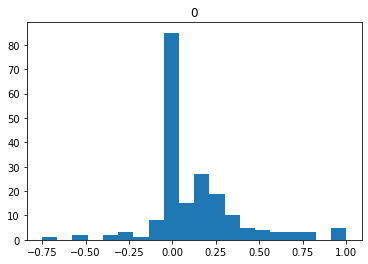

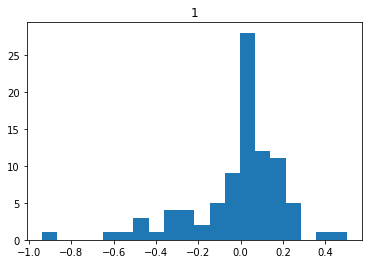

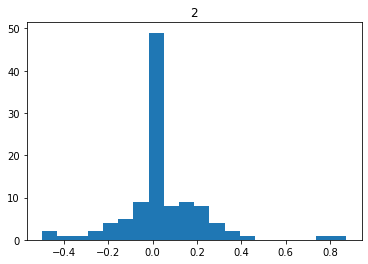

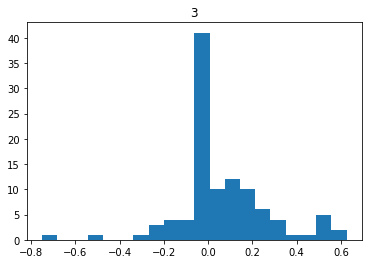

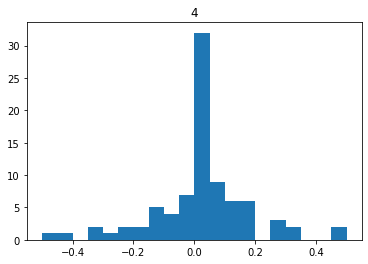

In [20]:
for i in range(0,5):
    plt.hist(sentiment_dict[str(i)], bins = 20)
    plt.title(str(i))
    plt.show()

In [21]:
count = 0
for i in sentiment_dict.values():
    print(f"code {count}'s negative proportion: {len([j for j in i if j < 0])/len(i)}")
    count += 1

code 0's negative proportion: 0.09693877551020408
code 1's negative proportion: 0.34831460674157305
code 2's negative proportion: 0.2336448598130841
code 3's negative proportion: 0.1792452830188679
code 4's negative proportion: 0.29411764705882354


We can see that phase 1 has the highest negative sentiment proportion and phase 0 has the lowest. 
The above result makes sense since in phase 1, students tend to show a sense of puzzlement, which is closely related to the negative sentiment. Phase 0 contains socializing comments and self introductions, and those tend to be positive.  